In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, os, joblib
from datetime import datetime, timedelta

# ML Models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

REGIONS = ['DELHI', 'BRPL', 'BYPL', 'NDPL', 'NDMC', 'MES']
RANDOM_STATE = 42
print('✅ Imports done')

✅ Imports done


In [3]:
DELHI_HOLIDAYS = [
    # 2022
    '2022-01-26','2022-03-01','2022-03-18','2022-04-10','2022-04-14',
    '2022-04-15','2022-05-03','2022-05-16','2022-07-10','2022-08-09',
    '2022-08-15','2022-08-19','2022-10-02','2022-10-05','2022-10-09',
    '2022-10-24','2022-10-25','2022-10-26','2022-11-08','2022-12-25',
    # 2023
    '2023-01-26','2023-02-18','2023-03-08','2023-03-30','2023-04-07',
    '2023-04-14','2023-04-21','2023-04-22','2023-05-05','2023-06-29',
    '2023-07-29','2023-08-15','2023-09-06','2023-09-07','2023-09-19',
    '2023-10-02','2023-10-24','2023-11-13','2023-11-14','2023-11-15',
    '2023-11-27','2023-12-25',
    # 2024
    '2024-01-22','2024-01-26','2024-03-08','2024-03-25','2024-03-29',
    '2024-04-09','2024-04-11','2024-04-14','2024-04-17','2024-05-23',
    '2024-06-17','2024-07-17','2024-08-15','2024-08-26','2024-09-16',
    '2024-10-02','2024-10-12','2024-10-13','2024-11-01','2024-11-02',
    '2024-11-03','2024-11-15','2024-12-25',
    # 2025
    '2025-01-26','2025-02-26','2025-03-14','2025-03-31','2025-04-06',
    '2025-04-10','2025-04-14','2025-05-12','2025-06-07','2025-07-06',
    '2025-08-15','2025-08-16','2025-09-05','2025-10-02','2025-10-20',
    '2025-10-21','2025-11-05','2025-12-25',
    # 2026
    '2026-01-26','2026-02-15','2026-03-20','2026-03-22','2026-03-27',
    '2026-03-29','2026-04-14'
]
HOLIDAY_SET = set(DELHI_HOLIDAYS)
print(f'✅ Loaded {len(HOLIDAY_SET)} unique holiday dates')

# Holiday impact summary
by_year = {}
for d in HOLIDAY_SET:
    yr = d[:4]
    by_year[yr] = by_year.get(yr, 0) + 1
for yr in sorted(by_year):
    print(f'  {yr}: {by_year[yr]} holidays')

✅ Loaded 90 unique holiday dates
  2022: 20 holidays
  2023: 22 holidays
  2024: 23 holidays
  2025: 18 holidays
  2026: 7 holidays


In [5]:
# ── IMPORTANT: Update paths if needed ──
SLDC_PATH    = 'delhi_sldc_5min_2022_2026.csv'   # electricity demand
WEATHER_PATH = 'Delhi_Weather_5M.csv'             # weather (5-min interpolated)

sldc = pd.read_csv(SLDC_PATH)
wx   = pd.read_csv(WEATHER_PATH)

# Parse datetime
sldc['datetime'] = pd.to_datetime(sldc['Date'] + ' ' + sldc['TimeSlot'], dayfirst=True)
wx['datetime']   = pd.to_datetime(wx['Date']   + ' ' + wx['TimeSlot'],   dayfirst=True)

sldc.sort_values('datetime', inplace=True)
wx.sort_values('datetime',   inplace=True)
sldc.reset_index(drop=True, inplace=True)
wx.reset_index(drop=True,   inplace=True)

print(f'SLDC  : {sldc.shape} | {sldc["datetime"].min()} → {sldc["datetime"].max()}')
print(f'Weather: {wx.shape}  | {wx["datetime"].min()} → {wx["datetime"].max()}')
print('\nSLDC columns:', list(sldc.columns))
print('Weather columns:', list(wx.columns))

SLDC  : (430782, 9) | 2022-01-01 00:00:00 → 2026-04-01 23:55:00
Weather: (446965, 12)  | 2022-01-01 00:00:00 → 2026-04-01 23:00:00

SLDC columns: ['Date', 'TimeSlot', 'DELHI', 'BRPL', 'BYPL', 'NDPL', 'NDMC', 'MES', 'datetime']
Weather columns: ['Date', 'TimeSlot', 'Temperature (°C)', 'Relative Humidity (%)', 'Apparent Temperature (°C)', 'Precipitation (mm)', 'Wind Speed (m/s)', 'Cloud Cover Total (%)', 'Cloud Cover Low (%)', 'Cloud Cover Mid (%)', 'Cloud Cover High (%)', 'datetime']


In [7]:
print('=== SLDC Demand Stats (MW) ===')
print(sldc[REGIONS].describe().round(2))

print('\n=== Missing Values ===')
print(sldc[REGIONS].isnull().sum())
print(wx[['Temperature (°C)','Relative Humidity (%)','Apparent Temperature (°C)',
          'Precipitation (mm)','Wind Speed (m/s)','Cloud Cover Total (%)']].isnull().sum())

=== SLDC Demand Stats (MW) ===
           DELHI       BRPL       BYPL       NDPL       NDMC        MES
count  430782.00  430782.00  430782.00  430782.00  430782.00  430782.00
mean     4121.60    1754.60     882.36    1240.02     176.76      27.93
std      1313.69     587.57     323.57     414.56      63.42       8.54
min      1302.08     470.73     229.03 -124343.88       2.67       0.00
25%      3237.82    1349.61     676.79    1001.99     130.61      21.53
50%      4021.70    1695.80     857.73    1238.57     165.16      27.25
75%      5061.94    2166.56    1109.52    1501.52     207.23      33.50
max      8631.53   64333.16   63516.52    2680.85     440.95      61.44

=== Missing Values ===
DELHI    0
BRPL     0
BYPL     0
NDPL     0
NDMC     0
MES      0
dtype: int64
Temperature (°C)             0
Relative Humidity (%)        0
Apparent Temperature (°C)    0
Precipitation (mm)           0
Wind Speed (m/s)             0
Cloud Cover Total (%)        0
dtype: int64


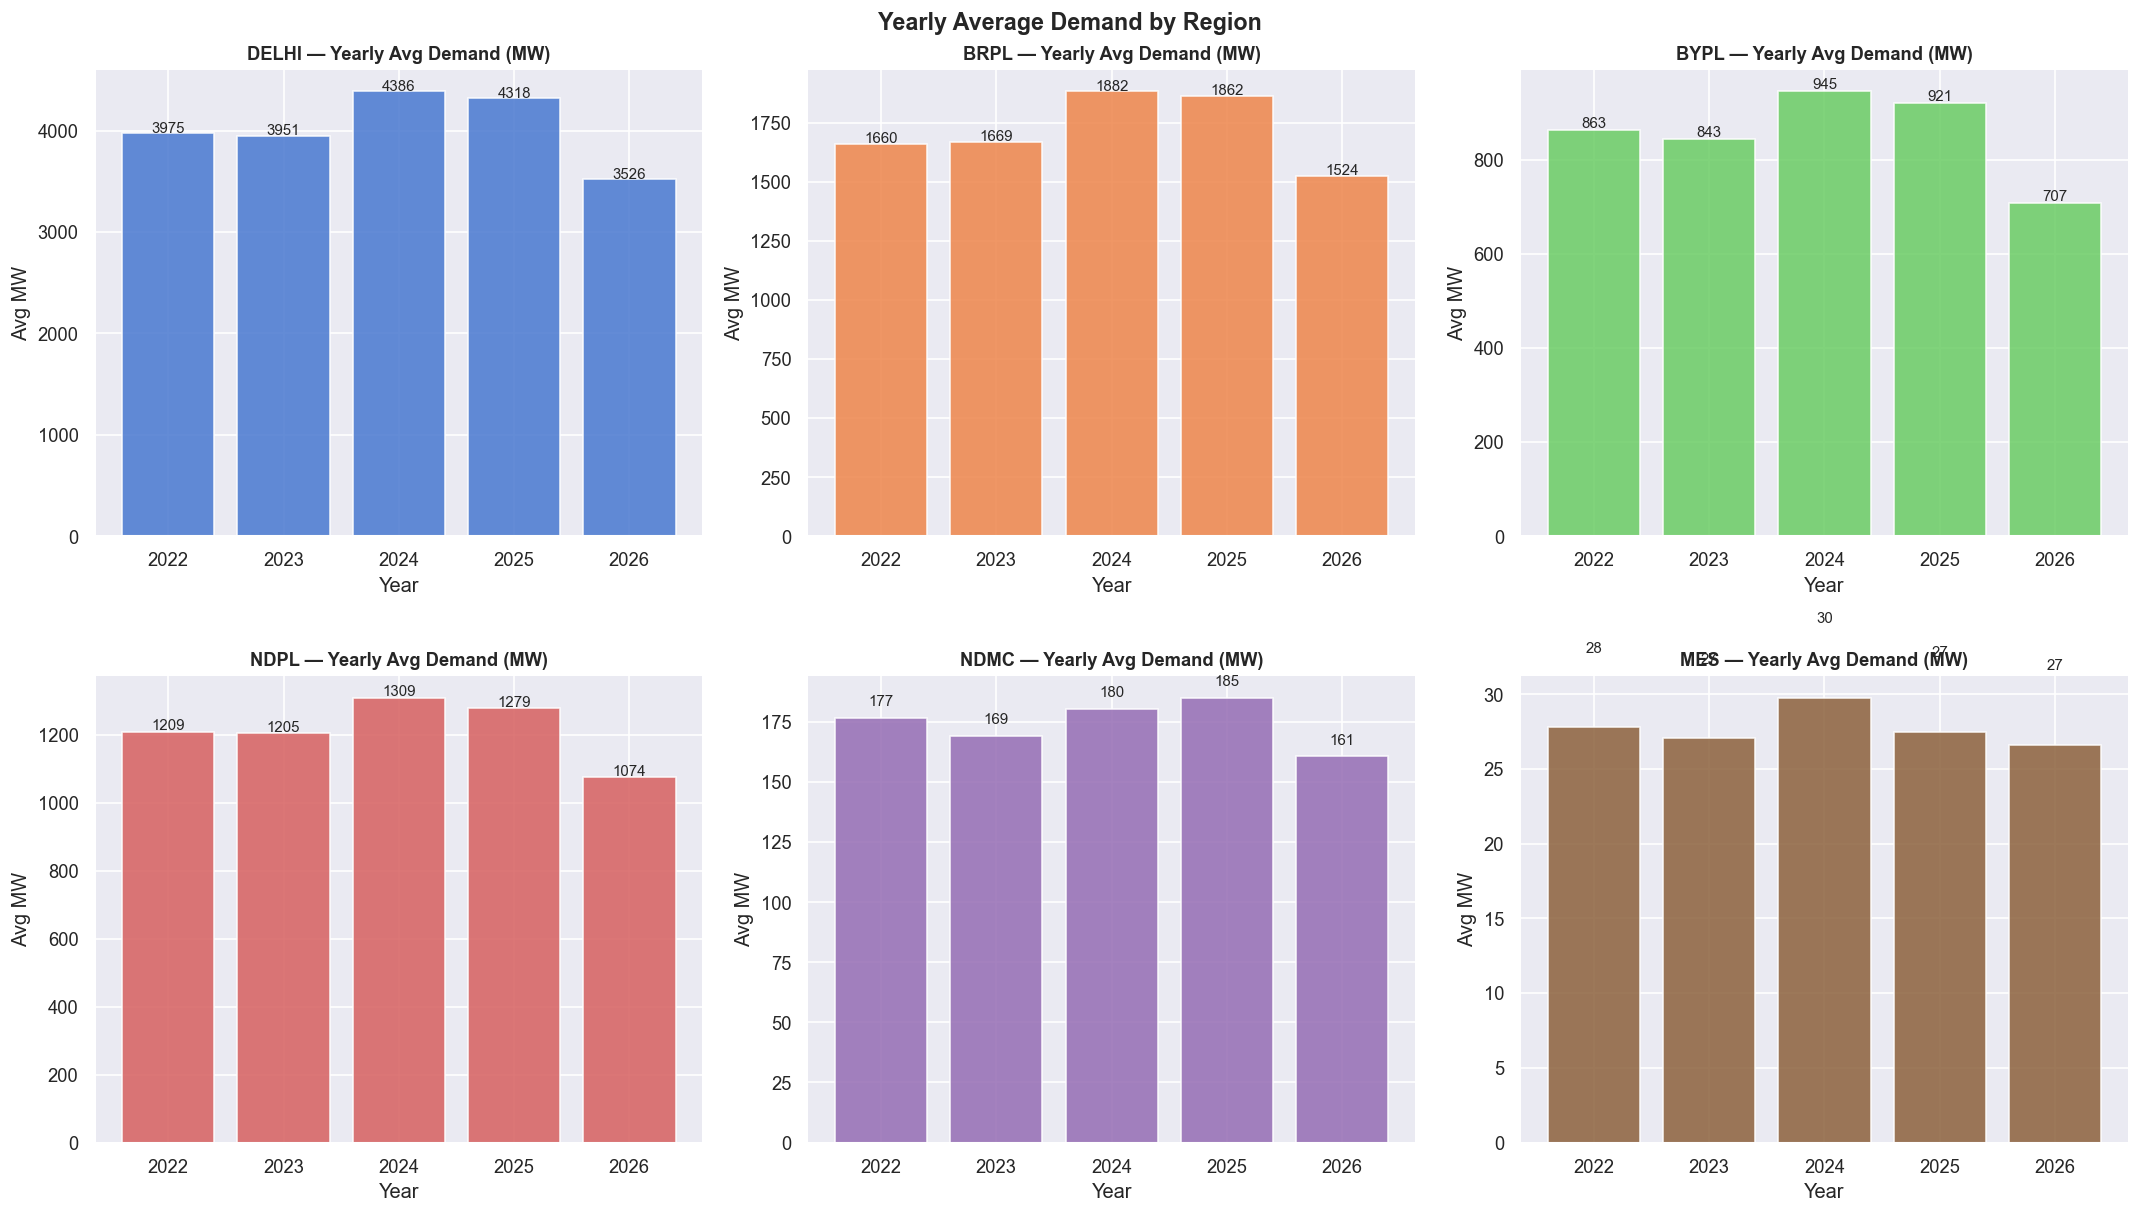

Key insight: 2024 saw highest demand — likely due to extreme heat wave


In [9]:
sldc['year']  = sldc['datetime'].dt.year
sldc['month'] = sldc['datetime'].dt.month
sldc['hour']  = sldc['datetime'].dt.hour
sldc['dow']   = sldc['datetime'].dt.dayofweek

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, r in enumerate(REGIONS):
    yearly = sldc.groupby('year')[r].mean()
    axes[i].bar(yearly.index, yearly.values, color=sns.color_palette('muted')[i], alpha=0.85)
    axes[i].set_title(f'{r} — Yearly Avg Demand (MW)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Year'); axes[i].set_ylabel('Avg MW')
    for x, y in zip(yearly.index, yearly.values):
        axes[i].text(x, y+5, f'{y:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.suptitle('Yearly Average Demand by Region', y=1.01, fontsize=14, fontweight='bold')
plt.savefig('01_yearly_demand.png', bbox_inches='tight')
plt.show()
print('Key insight: 2024 saw highest demand — likely due to extreme heat wave')

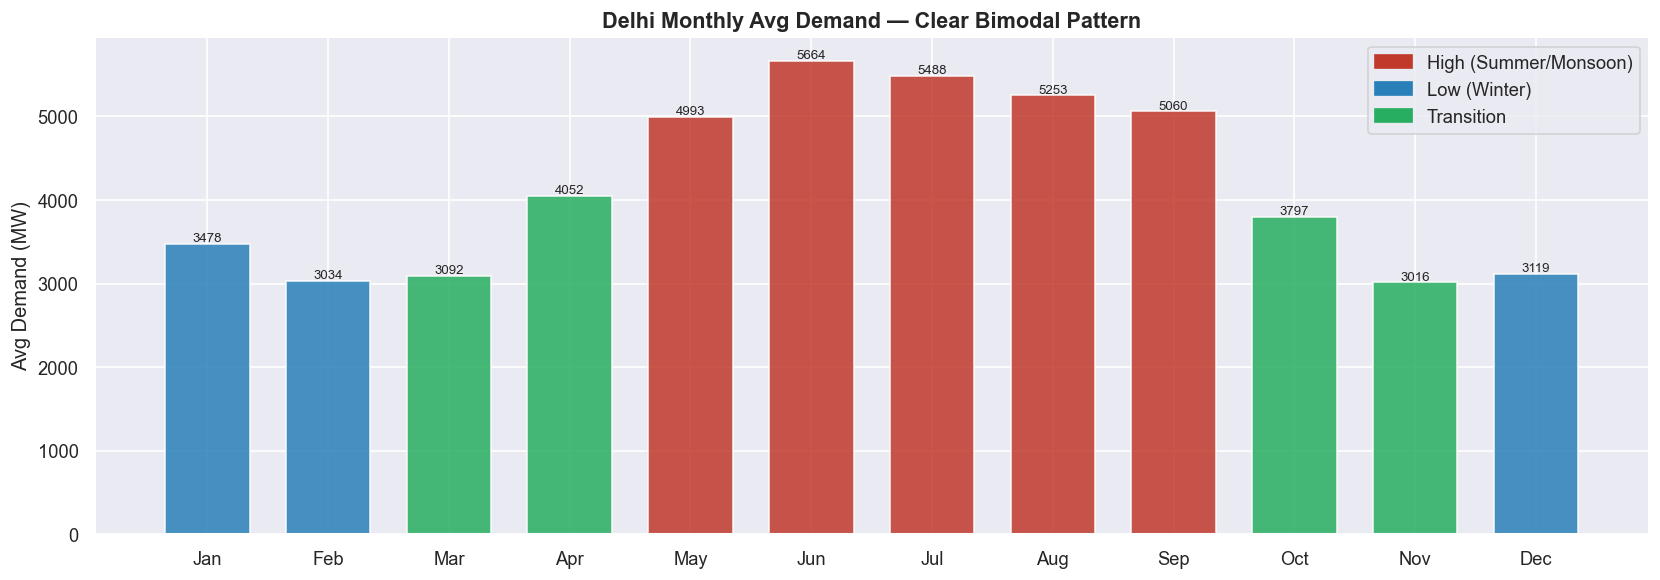

Peak months: Jun-Sep (AC + industrial load)
Trough months: Feb-Mar, Nov


In [11]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = sldc.groupby('month')['DELHI'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#c0392b' if m in [5,6,7,8,9] else '#2980b9' if m in [1,2,12] else '#27ae60' for m in range(1,13)]
bars = ax.bar(range(1,13), monthly.values, color=colors, alpha=0.85, width=0.7)
ax.set_xticks(range(1,13)); ax.set_xticklabels(months)
ax.set_ylabel('Avg Demand (MW)'); ax.set_title('Delhi Monthly Avg Demand — Clear Bimodal Pattern', fontsize=13, fontweight='bold')
from matplotlib.patches import Patch
legend = [Patch(color='#c0392b',label='High (Summer/Monsoon)'), Patch(color='#2980b9',label='Low (Winter)'), Patch(color='#27ae60',label='Transition')]
ax.legend(handles=legend)
for bar, v in zip(bars, monthly.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+30, f'{v:.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('02_monthly_seasonality.png', bbox_inches='tight')
plt.show()
print('Peak months: Jun-Sep (AC + industrial load)')
print('Trough months: Feb-Mar, Nov')

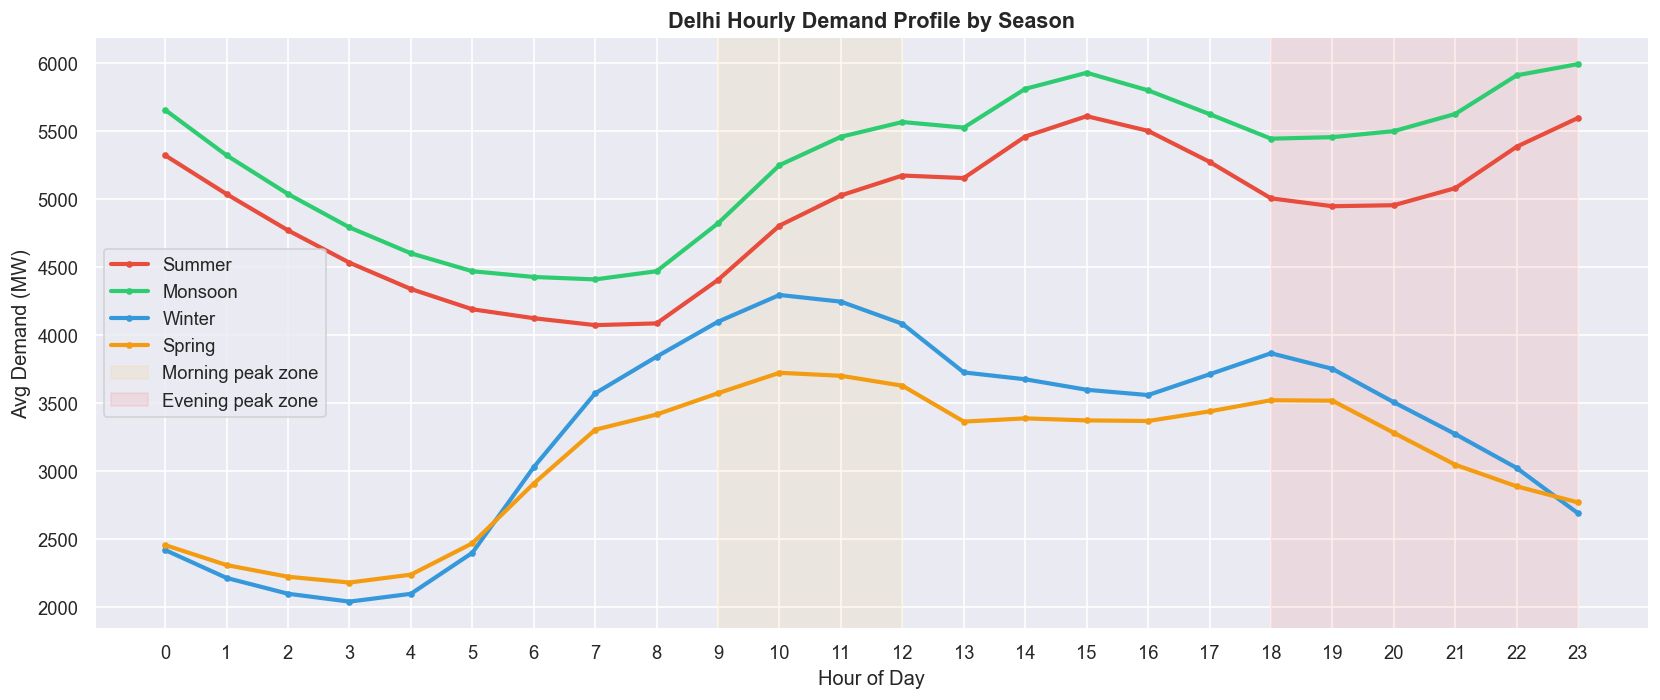

Season-wise peak hours:
  Summer: Morning peak=12h, Evening peak=22h
  Monsoon: Morning peak=12h, Evening peak=22h
  Winter: Morning peak=10h, Evening peak=18h


In [13]:
def get_season(m):
    if m in [4,5,6]: return 'Summer'
    elif m in [7,8,9]: return 'Monsoon'
    elif m in [10,11,12,1,2]: return 'Winter'
    else: return 'Spring'

sldc['season'] = sldc['month'].apply(get_season)

fig, ax = plt.subplots(figsize=(14, 6))
palette = {'Summer':'#e74c3c','Monsoon':'#2ecc71','Winter':'#3498db','Spring':'#f39c12'}
for s, color in palette.items():
    sub = sldc[sldc['season']==s].groupby('hour')['DELHI'].mean()
    ax.plot(sub.index, sub.values, label=s, color=color, linewidth=2.5, marker='o', markersize=3)

ax.set_xlabel('Hour of Day'); ax.set_ylabel('Avg Demand (MW)')
ax.set_title('Delhi Hourly Demand Profile by Season', fontsize=13, fontweight='bold')
ax.set_xticks(range(24))
ax.axvspan(9,12, alpha=0.07, color='orange', label='Morning peak zone')
ax.axvspan(18,23, alpha=0.07, color='red', label='Evening peak zone')
ax.legend()
plt.tight_layout()
plt.savefig('03_hourly_profile.png', bbox_inches='tight')
plt.show()

print('Season-wise peak hours:')
for s in ['Summer','Monsoon','Winter']:
    sub = sldc[sldc['season']==s].groupby('hour')['DELHI'].mean()
    print(f"  {s}: Morning peak={sub[9:13].idxmax()}h, Evening peak={sub[17:23].idxmax()}h")

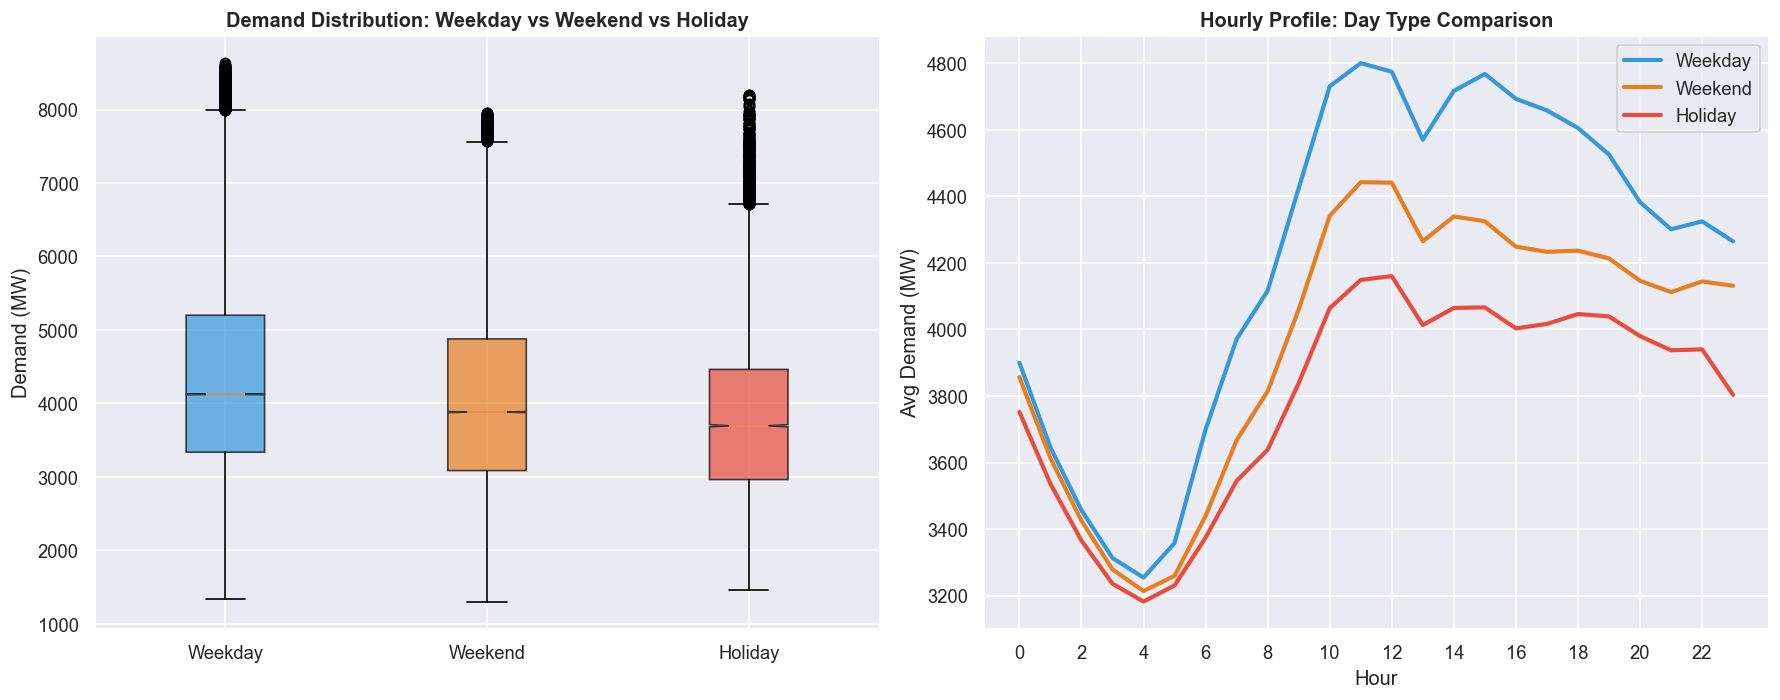

Weekday   : 4214.0 MW avg
Weekend   : 3964.4 MW avg
Holiday   : 3789.6 MW avg

📉 Holiday reduces demand by 10.1% vs Weekday


In [15]:
sldc['date_str']   = sldc['datetime'].dt.strftime('%Y-%m-%d')
sldc['is_holiday'] = sldc['date_str'].isin(HOLIDAY_SET).astype(int)
sldc['is_weekend'] = (sldc['dow'] >= 5).astype(int)

def day_type(row):
    if row['is_holiday']:  return 'Holiday'
    elif row['is_weekend']: return 'Weekend'
    else: return 'Weekday'

sldc['day_type'] = sldc.apply(day_type, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot
order = ['Weekday','Weekend','Holiday']
colors_box = {'Weekday':'#3498db','Weekend':'#e67e22','Holiday':'#e74c3c'}
bp_data = [sldc[sldc['day_type']==d]['DELHI'].values for d in order]
bp = axes[0].boxplot(bp_data, labels=order, patch_artist=True, notch=True)
for patch, d in zip(bp['boxes'], order):
    patch.set_facecolor(colors_box[d])
    patch.set_alpha(0.7)
axes[0].set_ylabel('Demand (MW)')
axes[0].set_title('Demand Distribution: Weekday vs Weekend vs Holiday', fontweight='bold')

# Hourly profile comparison
for dt in order:
    sub = sldc[sldc['day_type']==dt].groupby('hour')['DELHI'].mean()
    axes[1].plot(sub.index, sub.values, label=dt, color=colors_box[dt], linewidth=2.5)
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Avg Demand (MW)')
axes[1].set_title('Hourly Profile: Day Type Comparison', fontweight='bold')
axes[1].legend(); axes[1].set_xticks(range(0,24,2))

plt.tight_layout()
plt.savefig('04_holiday_impact.png', bbox_inches='tight')
plt.show()

for dt in order:
    avg = sldc[sldc['day_type']==dt]['DELHI'].mean()
    print(f'{dt:10s}: {avg:.1f} MW avg')
wkd = sldc[sldc['day_type']=='Weekday']['DELHI'].mean()
hol = sldc[sldc['day_type']=='Holiday']['DELHI'].mean()
print(f'\n📉 Holiday reduces demand by {(1-hol/wkd)*100:.1f}% vs Weekday')

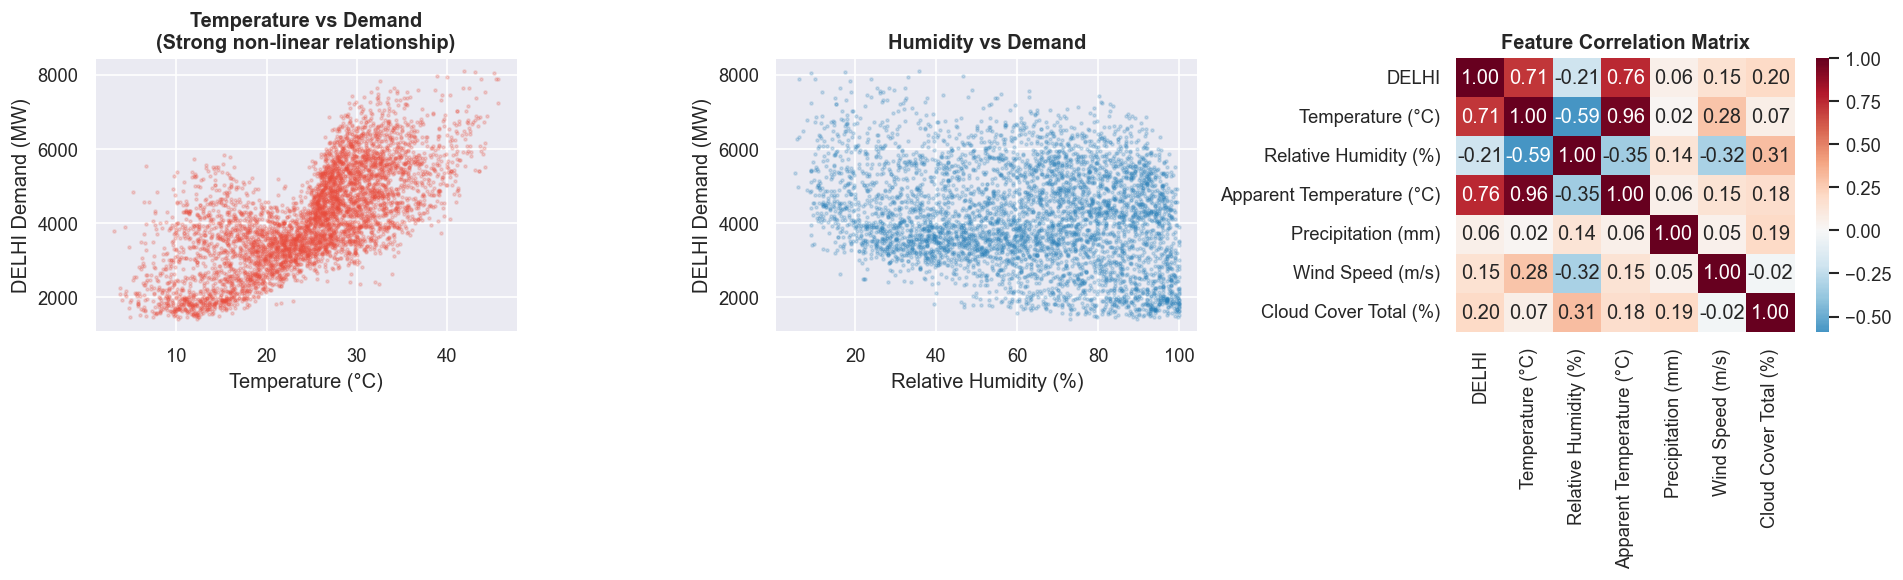

Correlation with DELHI demand:
Apparent Temperature (°C)    0.756262
Temperature (°C)             0.710027
Cloud Cover Total (%)        0.197317
Wind Speed (m/s)             0.150930
Precipitation (mm)           0.060964
Relative Humidity (%)       -0.208817
Name: DELHI, dtype: float64


In [17]:
# Merge for correlation
wx_tmp = wx[['datetime','Temperature (°C)','Relative Humidity (%)','Apparent Temperature (°C)',
             'Precipitation (mm)','Wind Speed (m/s)','Cloud Cover Total (%)']].copy()
merged_tmp = pd.merge(sldc[['datetime','DELHI']], wx_tmp, on='datetime', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Temp vs Demand
sample = merged_tmp.sample(5000, random_state=42)
axes[0].scatter(sample['Temperature (°C)'], sample['DELHI'], alpha=0.2, s=3, c='#e74c3c')
axes[0].set_xlabel('Temperature (°C)'); axes[0].set_ylabel('DELHI Demand (MW)')
axes[0].set_title('Temperature vs Demand\n(Strong non-linear relationship)', fontweight='bold')

# Humidity vs Demand
axes[1].scatter(sample['Relative Humidity (%)'], sample['DELHI'], alpha=0.2, s=3, c='#2980b9')
axes[1].set_xlabel('Relative Humidity (%)'); axes[1].set_ylabel('DELHI Demand (MW)')
axes[1].set_title('Humidity vs Demand', fontweight='bold')

# Correlation heatmap
corr = merged_tmp[['DELHI','Temperature (°C)','Relative Humidity (%)','Apparent Temperature (°C)',
                    'Precipitation (mm)','Wind Speed (m/s)','Cloud Cover Total (%)']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[2], cbar=True)
axes[2].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('05_weather_correlation.png', bbox_inches='tight')
plt.show()

print('Correlation with DELHI demand:')
print(corr['DELHI'].drop('DELHI').sort_values(ascending=False))

In [19]:
print('=== Outlier Analysis (1st–99th percentile method) ===')
OUTLIER_BOUNDS = {}
for r in REGIONS:
    q_low  = sldc[r].quantile(0.005)
    q_high = sldc[r].quantile(0.995)
    n_out  = ((sldc[r] < q_low) | (sldc[r] > q_high)).sum()
    OUTLIER_BOUNDS[r] = (q_low, q_high)
    pct = n_out/len(sldc)*100
    print(f'{r:6s}: [{q_low:.1f} – {q_high:.1f}] MW | Outliers: {n_out} ({pct:.2f}%)')

# Special case: BRPL has a single extreme spike (64333 MW on 2023-12-28)
print(f'\n⚠️  BRPL spike check: max={sldc["BRPL"].max():.1f} MW on',
      sldc.loc[sldc['BRPL'].idxmax(), 'datetime'])

=== Outlier Analysis (1st–99th percentile method) ===
DELHI : [1568.6 – 7443.9] MW | Outliers: 4308 (1.00%)
BRPL  : [636.7 – 3308.6] MW | Outliers: 4307 (1.00%)
BYPL  : [273.4 – 1639.2] MW | Outliers: 4308 (1.00%)
NDPL  : [492.4 – 2132.5] MW | Outliers: 4306 (1.00%)
NDMC  : [78.0 – 367.2] MW | Outliers: 4305 (1.00%)
MES   : [12.6 – 51.5] MW | Outliers: 4277 (0.99%)

⚠️  BRPL spike check: max=64333.2 MW on 2023-12-28 17:30:00


In [23]:
# ── 5.1 Merge SLDC + Weather on datetime ──
wx_feats = wx[['datetime','Temperature (°C)','Relative Humidity (%)',
               'Apparent Temperature (°C)','Precipitation (mm)',
               'Wind Speed (m/s)','Cloud Cover Total (%)']].copy()
wx_feats.rename(columns={'Apparent Temperature (°C)':'feels_like'}, inplace=True)

df = pd.merge(sldc, wx_feats, on='datetime', how='inner')
print(f'Merged shape: {df.shape}')

# ── 5.2 Remove Outliers (Winsorize at 0.5–99.5%) ──
print('\nRemoving outliers...')
before = len(df)
for r in REGIONS:
    lo, hi = df[r].quantile(0.005), df[r].quantile(0.995)
    df[r] = df[r].clip(lo, hi)

# Remove the BRPL spike explicitly
df = df[df['BRPL'] < 10000].copy()
after = len(df)
print(f'Outliers handled: {before - after} rows removed/clipped')

# ── 5.3 Time Features ──
df['hour']        = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month']       = df['datetime'].dt.month
df['year']        = df['datetime'].dt.year
df['day_of_year'] = df['datetime'].dt.dayofyear
df['week_of_year']= df['datetime'].dt.isocalendar().week.astype(int)
df['date_str']    = df['datetime'].dt.strftime('%Y-%m-%d')
df['season']      = df['month'].apply(get_season)

# ── 5.4 Cyclic Features ──
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)

# ── 5.5 Flag Features ──
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_holiday'] = df['date_str'].isin(HOLIDAY_SET).astype(int)
df['is_monsoon'] = df['month'].isin([7,8,9]).astype(int)
df['is_summer']  = df['month'].isin([4,5,6]).astype(int)
df['is_winter']  = df['month'].isin([10,11,12,1,2]).astype(int)

# ── 5.6 Season-Aware Peak Flags ──
# Based on EDA: summer/monsoon peaks 12h+22h, winter peaks 10h+18h
def is_morning_peak(row):
    h, s = row['hour'], row['season']
    if s == 'Winter': return int(9 <= h <= 11)
    elif s in ['Summer','Monsoon']: return int(11 <= h <= 13)
    else: return int(10 <= h <= 12)  # Spring

def is_evening_peak(row):
    h, s = row['hour'], row['season']
    if s == 'Winter': return int(17 <= h <= 19)
    elif s in ['Summer','Monsoon']: return int(20 <= h <= 23)
    else: return int(18 <= h <= 21)  # Spring

df['is_morning_peak'] = df.apply(is_morning_peak, axis=1)
df['is_evening_peak'] = df.apply(is_evening_peak, axis=1)

# ── 5.7 Year trend feature (normalized) ──
df['year_norm'] = (df['year'] - 2022) / 5  # 0 to 1 range

print('\n✅ Feature engineering complete')
print(f'Dataset shape: {df.shape}')

Merged shape: (430771, 24)

Removing outliers...
Outliers handled: 0 rows removed/clipped

✅ Feature engineering complete
Dataset shape: (430771, 39)


In [25]:
# For prediction we need hourly output (matching Open-Meteo API)
# → Aggregate all 5-min slots into hourly means

df['hour_dt'] = df['datetime'].dt.floor('h')

agg_dict = {r: 'mean' for r in REGIONS}
agg_dict.update({
    'Temperature (°C)': 'mean',
    'Relative Humidity (%)': 'mean',
    'feels_like': 'mean',
    'Precipitation (mm)': 'sum',
    'Wind Speed (m/s)': 'mean',
    'Cloud Cover Total (%)': 'mean',
    'hour': 'first',
    'day_of_week': 'first',
    'month': 'first',
    'year': 'first',
    'day_of_year': 'first',
    'week_of_year': 'first',
    'year_norm': 'first',
    'hour_sin': 'first', 'hour_cos': 'first',
    'month_sin': 'first', 'month_cos': 'first',
    'dow_sin': 'first', 'dow_cos': 'first',
    'is_weekend': 'first',
    'is_holiday': 'first',
    'is_monsoon': 'first',
    'is_summer': 'first',
    'is_winter': 'first',
    'is_morning_peak': 'first',
    'is_evening_peak': 'first',
    'season': 'first',
    'date_str': 'first'
})

df_hourly = df.groupby('hour_dt').agg(agg_dict).reset_index()
df_hourly.rename(columns={'hour_dt':'datetime'}, inplace=True)

print(f'Hourly dataset: {df_hourly.shape}')
print(f'Date range: {df_hourly["datetime"].min()} → {df_hourly["datetime"].max()}')
print(f'Expected rows (4 years + ~4 months): ~{int((df_hourly.shape[0]))} hours')

Hourly dataset: (36193, 35)
Date range: 2022-01-01 00:00:00 → 2026-04-01 23:00:00
Expected rows (4 years + ~4 months): ~36193 hours


In [27]:
FEATURES = [
    # Time - Raw
    'hour', 'day_of_week', 'month', 'year', 'day_of_year', 'week_of_year', 'year_norm',
    # Time - Cyclic
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # Season-aware peaks
    'is_morning_peak', 'is_evening_peak',
    # Flags
    'is_weekend', 'is_holiday', 'is_monsoon', 'is_summer', 'is_winter',
    # Weather
    'Temperature (°C)', 'Relative Humidity (%)', 'feels_like',
    'Precipitation (mm)', 'Wind Speed (m/s)', 'Cloud Cover Total (%)'
]

print(f'✅ Total features: {len(FEATURES)}')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')

# Verify all features exist
missing = [f for f in FEATURES if f not in df_hourly.columns]
if missing:
    print(f'\n❌ Missing features: {missing}')
else:
    print('\n✅ All features present in dataset')

✅ Total features: 26
   1. hour
   2. day_of_week
   3. month
   4. year
   5. day_of_year
   6. week_of_year
   7. year_norm
   8. hour_sin
   9. hour_cos
  10. month_sin
  11. month_cos
  12. dow_sin
  13. dow_cos
  14. is_morning_peak
  15. is_evening_peak
  16. is_weekend
  17. is_holiday
  18. is_monsoon
  19. is_summer
  20. is_winter
  21. Temperature (°C)
  22. Relative Humidity (%)
  23. feels_like
  24. Precipitation (mm)
  25. Wind Speed (m/s)
  26. Cloud Cover Total (%)

✅ All features present in dataset


In [29]:
# 80/20 Train-Test Split (chronological, no shuffle)

split_idx = int(len(df_hourly) * 0.80)

train_df = df_hourly.iloc[:split_idx].copy()
test_df  = df_hourly.iloc[split_idx:].copy()

print(f'Train size: {len(train_df):,} hourly records ({train_df["datetime"].min().date()} → {train_df["datetime"].max().date()})')
print(f'Test  size: {len(test_df):,} hourly records ({test_df["datetime"].min().date()} → {test_df["datetime"].max().date()})')
print(f'\nTrain/Test split: {len(train_df)/(len(train_df)+len(test_df))*100:.1f}% / {len(test_df)/(len(train_df)+len(test_df))*100:.1f}%')

X_train = train_df[FEATURES]
X_test  = test_df[FEATURES]

print('\n✅ Split complete')

Train size: 28,954 hourly records (2022-01-01 → 2025-06-01)
Test  size: 7,239 hourly records (2025-06-01 → 2026-04-01)

Train/Test split: 80.0% / 20.0%

✅ Split complete


In [31]:
# ── Helper: Metrics ──
def compute_metrics(y_true, y_pred, region=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    acc  = 100 - mape  # accuracy as (100 - MAPE)
    return {'region': region, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'Accuracy': acc}

# Storage
all_models    = {}   # {region: {'xgb': model, 'lgb': model, 'cat': model}}
all_weights   = {}   # {region: {'xgb': w, 'lgb': w, 'cat': w}}
all_metrics   = []   # list of dicts
all_preds     = {}   # {region: y_pred_test_ensemble}

# Validation: use last 3 months of training data
val_cutoff = train_df['datetime'].max() - pd.DateOffset(months=3)
train_inner = train_df[train_df['datetime'] <= val_cutoff]
val_df      = train_df[train_df['datetime'] > val_cutoff]

X_train_inner = train_inner[FEATURES]
X_val         = val_df[FEATURES]

print(f'Inner train: {len(train_inner):,} | Validation: {len(val_df):,}')
print('\n' + '='*65)

for region in REGIONS:
    print(f'\n🔄 Training models for: {region}')
    
    y_train_inner = train_inner[region]
    y_val         = val_df[region]
    y_train_full  = train_df[region]
    y_test        = test_df[region]
    
    # ── XGBoost ──
    xgb_model = xgb.XGBRegressor(
        n_estimators      = 1200,
        learning_rate     = 0.04,
        max_depth         = 7,
        subsample         = 0.80,
        colsample_bytree  = 0.80,
        min_child_weight  = 5,
        reg_alpha         = 0.1,
        reg_lambda        = 1.5,
        gamma             = 0.05,
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        tree_method       = 'hist',
        early_stopping_rounds = 50,
        eval_metric       = 'mae'
    )
    xgb_model.fit(X_train_inner, y_train_inner,
                  eval_set=[(X_val, y_val)], verbose=False)
    xgb_val_pred  = xgb_model.predict(X_val)
    xgb_val_mae   = mean_absolute_error(y_val, xgb_val_pred)
    
    # Retrain on full training data
    xgb_final = xgb.XGBRegressor(
        n_estimators      = xgb_model.best_iteration + 50,
        learning_rate     = 0.04,
        max_depth         = 7,
        subsample         = 0.80,
        colsample_bytree  = 0.80,
        min_child_weight  = 5,
        reg_alpha         = 0.1,
        reg_lambda        = 1.5,
        gamma             = 0.05,
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        tree_method       = 'hist'
    )
    xgb_final.fit(X_train, y_train_full)
    print(f'  XGBoost  : best_iter={xgb_model.best_iteration}, val_MAE={xgb_val_mae:.2f}')
    
    # ── LightGBM ──
    lgb_model = lgb.LGBMRegressor(
        n_estimators      = 1500,
        learning_rate     = 0.03,
        num_leaves        = 63,
        max_depth         = -1,
        min_child_samples = 20,
        subsample         = 0.80,
        colsample_bytree  = 0.80,
        reg_alpha         = 0.1,
        reg_lambda        = 1.5,
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbose           = -1
    )
    lgb_model.fit(X_train_inner, y_train_inner,
                  eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    lgb_val_pred = lgb_model.predict(X_val)
    lgb_val_mae  = mean_absolute_error(y_val, lgb_val_pred)
    
    lgb_final = lgb.LGBMRegressor(
        n_estimators      = lgb_model.best_iteration_ + 50,
        learning_rate     = 0.03,
        num_leaves        = 63,
        min_child_samples = 20,
        subsample         = 0.80,
        colsample_bytree  = 0.80,
        reg_alpha         = 0.1,
        reg_lambda        = 1.5,
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbose           = -1
    )
    lgb_final.fit(X_train, y_train_full)
    print(f'  LightGBM : best_iter={lgb_model.best_iteration_}, val_MAE={lgb_val_mae:.2f}')
    
    # ── CatBoost ──
    cat_model = CatBoostRegressor(
        iterations         = 1500,
        learning_rate      = 0.04,
        depth              = 7,
        l2_leaf_reg        = 3.0,
        subsample          = 0.80,
        colsample_bylevel  = 0.80,
        min_data_in_leaf   = 20,
        od_type            = 'Iter',
        od_wait            = 50,
        random_seed        = RANDOM_STATE,
        verbose            = 0
    )
    cat_model.fit(X_train_inner, y_train_inner,
                  eval_set=(X_val, y_val))
    cat_val_pred = cat_model.predict(X_val)
    cat_val_mae  = mean_absolute_error(y_val, cat_val_pred)
    
    cat_final = CatBoostRegressor(
        iterations         = cat_model.best_iteration_ + 50,
        learning_rate      = 0.04,
        depth              = 7,
        l2_leaf_reg        = 3.0,
        subsample          = 0.80,
        colsample_bylevel  = 0.80,
        min_data_in_leaf   = 20,
        random_seed        = RANDOM_STATE,
        verbose            = 0
    )
    cat_final.fit(X_train, y_train_full)
    print(f'  CatBoost : best_iter={cat_model.best_iteration_}, val_MAE={cat_val_mae:.2f}')
    
    # ── Compute Weighted Ensemble Weights ──
    # Weight = 1/MAE, normalized. Better model (lower MAE) → higher weight
    inv_maes = np.array([1/xgb_val_mae, 1/lgb_val_mae, 1/cat_val_mae])
    weights  = inv_maes / inv_maes.sum()
    all_weights[region] = {'xgb': weights[0], 'lgb': weights[1], 'cat': weights[2]}
    print(f'  Ensemble weights → XGB:{weights[0]:.3f}, LGB:{weights[1]:.3f}, CAT:{weights[2]:.3f}')
    
    # ── Test Predictions ──
    xgb_test = xgb_final.predict(X_test)
    lgb_test = lgb_final.predict(X_test)
    cat_test = cat_final.predict(X_test)
    ensemble_test = weights[0]*xgb_test + weights[1]*lgb_test + weights[2]*cat_test
    
    all_preds[region] = ensemble_test
    all_models[region] = {'xgb': xgb_final, 'lgb': lgb_final, 'cat': cat_final}
    
    # Metrics
    m_xgb = compute_metrics(y_test, xgb_test, f'{region}_XGB')
    m_lgb = compute_metrics(y_test, lgb_test, f'{region}_LGB')
    m_cat = compute_metrics(y_test, cat_test, f'{region}_CAT')
    m_ens = compute_metrics(y_test, ensemble_test, f'{region}_ENSEMBLE')
    all_metrics.extend([m_xgb, m_lgb, m_cat, m_ens])
    print(f'  ✅ Ensemble Test Accuracy: {m_ens["Accuracy"]:.2f}% | MAPE: {m_ens["MAPE"]:.2f}%')

print('\n' + '='*65)
print('✅ Training complete for all regions!')

Inner train: 26,758 | Validation: 2,196


🔄 Training models for: DELHI
  XGBoost  : best_iter=219, val_MAE=251.90
  LightGBM : best_iter=805, val_MAE=253.66
  CatBoost : best_iter=509, val_MAE=244.70
  Ensemble weights → XGB:0.331, LGB:0.329, CAT:0.341
  ✅ Ensemble Test Accuracy: 92.70% | MAPE: 7.30%

🔄 Training models for: BRPL
  XGBoost  : best_iter=77, val_MAE=120.14
  LightGBM : best_iter=124, val_MAE=123.32
  CatBoost : best_iter=444, val_MAE=115.07
  Ensemble weights → XGB:0.331, LGB:0.323, CAT:0.346
  ✅ Ensemble Test Accuracy: 92.77% | MAPE: 7.23%

🔄 Training models for: BYPL
  XGBoost  : best_iter=60, val_MAE=67.76
  LightGBM : best_iter=72, val_MAE=71.83
  CatBoost : best_iter=48, val_MAE=73.71
  Ensemble weights → XGB:0.349, LGB:0.330, CAT:0.321
  ✅ Ensemble Test Accuracy: 91.68% | MAPE: 8.32%

🔄 Training models for: NDPL
  XGBoost  : best_iter=253, val_MAE=75.38
  LightGBM : best_iter=216, val_MAE=81.46
  CatBoost : best_iter=360, val_MAE=76.16
  Ensemble weights → XGB:0.343

In [33]:
metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df.round({'MAE':2, 'RMSE':2, 'MAPE':3, 'R2':4, 'Accuracy':3})

print('=== FULL METRICS TABLE ===')
print(metrics_df.to_string(index=False))

print('\n=== ENSEMBLE ONLY — ALL REGIONS ===')
ens_only = metrics_df[metrics_df['region'].str.contains('ENSEMBLE')].copy()
ens_only['region'] = ens_only['region'].str.replace('_ENSEMBLE','')
print(ens_only.to_string(index=False))

=== FULL METRICS TABLE ===
        region    MAE   RMSE   MAPE     R2  Accuracy
     DELHI_XGB 301.34 382.23  7.393 0.9162    92.607
     DELHI_LGB 311.30 392.66  7.574 0.9116    92.426
     DELHI_CAT 289.78 367.43  7.197 0.9226    92.803
DELHI_ENSEMBLE 296.87 374.56  7.301 0.9195    92.699
      BRPL_XGB 133.56 171.76  7.359 0.9074    92.641
      BRPL_LGB 132.84 172.31  7.345 0.9068    92.655
      BRPL_CAT 129.12 166.18  7.280 0.9133    92.720
 BRPL_ENSEMBLE 130.07 167.62  7.230 0.9118    92.770
      BYPL_XGB  74.07  97.02  8.364 0.9073    91.636
      BYPL_LGB  76.63 100.41  8.574 0.9007    91.426
      BYPL_CAT  73.16  94.27  8.685 0.9125    91.315
 BYPL_ENSEMBLE  73.15  95.25  8.320 0.9106    91.680
      NDPL_XGB  95.51 125.96  8.155 0.8887    91.845
      NDPL_LGB  97.73 128.87  8.286 0.8835    91.714
      NDPL_CAT  93.65 124.45  8.035 0.8914    91.965
 NDPL_ENSEMBLE  94.46 124.82  8.064 0.8907    91.936
      NDMC_XGB  22.01  27.56 11.964 0.8006    88.036
      NDMC_LGB  21.

In [35]:
# ── Actual vs Predicted Demand (after training complete) ──

actual_vs_pred = {}

for region in REGIONS:
    y_actual = test_df[region].values
    y_pred   = all_preds[region]

    result_df = pd.DataFrame({
        'datetime': test_df['datetime'].values,
        'Actual_Demand': y_actual,
        'Predicted_Demand': np.round(y_pred, 2),
        'Error': np.round(y_actual - y_pred, 2),
        'Abs_Error': np.round(np.abs(y_actual - y_pred), 2)
    })

    actual_vs_pred[region] = result_df

    print(f"\n=== {region} : Actual vs Predicted ===")
    print(result_df.head(10).to_string(index=False))

print("\n✅ Stored in dictionary: actual_vs_pred['DELHI'], actual_vs_pred['BRPL'] etc.")


=== DELHI : Actual vs Predicted ===
           datetime  Actual_Demand  Predicted_Demand   Error  Abs_Error
2025-06-01 08:00:00    3980.052500           4370.34 -390.29     390.29
2025-06-01 09:00:00    4145.115000           4632.14 -487.03     487.03
2025-06-01 10:00:00    4340.500833           4653.42 -312.92     312.92
2025-06-01 11:00:00    4590.401667           4785.46 -195.06     195.06
2025-06-01 12:00:00    4879.020000           5062.59 -183.57     183.57
2025-06-01 13:00:00    5029.610000           5172.13 -142.52     142.52
2025-06-01 14:00:00    5434.582500           5285.14  149.44     149.44
2025-06-01 15:00:00    5653.434167           5530.71  122.72     122.72
2025-06-01 16:00:00    5176.654167           5401.09 -224.44     224.44
2025-06-01 17:00:00    4216.321667           4815.40 -599.08     599.08

=== BRPL : Actual vs Predicted ===
           datetime  Actual_Demand  Predicted_Demand   Error  Abs_Error
2025-06-01 08:00:00    1759.715000           2040.46 -280.74   

In [39]:
y_actual = test_df["DELHI"].values
y_pred   = all_preds["DELHI"]

result_df = pd.DataFrame({
    'datetime': test_df['datetime'].values,
    'Actual_Demand': y_actual,
    'Predicted_Demand': np.round(y_pred, 2),
    'Error': np.round(y_actual - y_pred, 2),
    'Abs_Error': np.round(np.abs(y_actual - y_pred), 2)
})

actual_vs_pred["DELHI"] = result_df

print(f"\n=== DELHI : Actual vs Predicted ===")
print(result_df.to_string(index=False))


=== DELHI : Actual vs Predicted ===
           datetime  Actual_Demand  Predicted_Demand    Error  Abs_Error
2025-06-01 08:00:00    3980.052500           4370.34  -390.29     390.29
2025-06-01 09:00:00    4145.115000           4632.14  -487.03     487.03
2025-06-01 10:00:00    4340.500833           4653.42  -312.92     312.92
2025-06-01 11:00:00    4590.401667           4785.46  -195.06     195.06
2025-06-01 12:00:00    4879.020000           5062.59  -183.57     183.57
2025-06-01 13:00:00    5029.610000           5172.13  -142.52     142.52
2025-06-01 14:00:00    5434.582500           5285.14   149.44     149.44
2025-06-01 15:00:00    5653.434167           5530.71   122.72     122.72
2025-06-01 16:00:00    5176.654167           5401.09  -224.44     224.44
2025-06-01 17:00:00    4216.321667           4815.40  -599.08     599.08
2025-06-01 18:00:00    4384.110000           4624.73  -240.62     240.62
2025-06-01 19:00:00    4532.915000           4763.15  -230.24     230.24
2025-06-01 20:

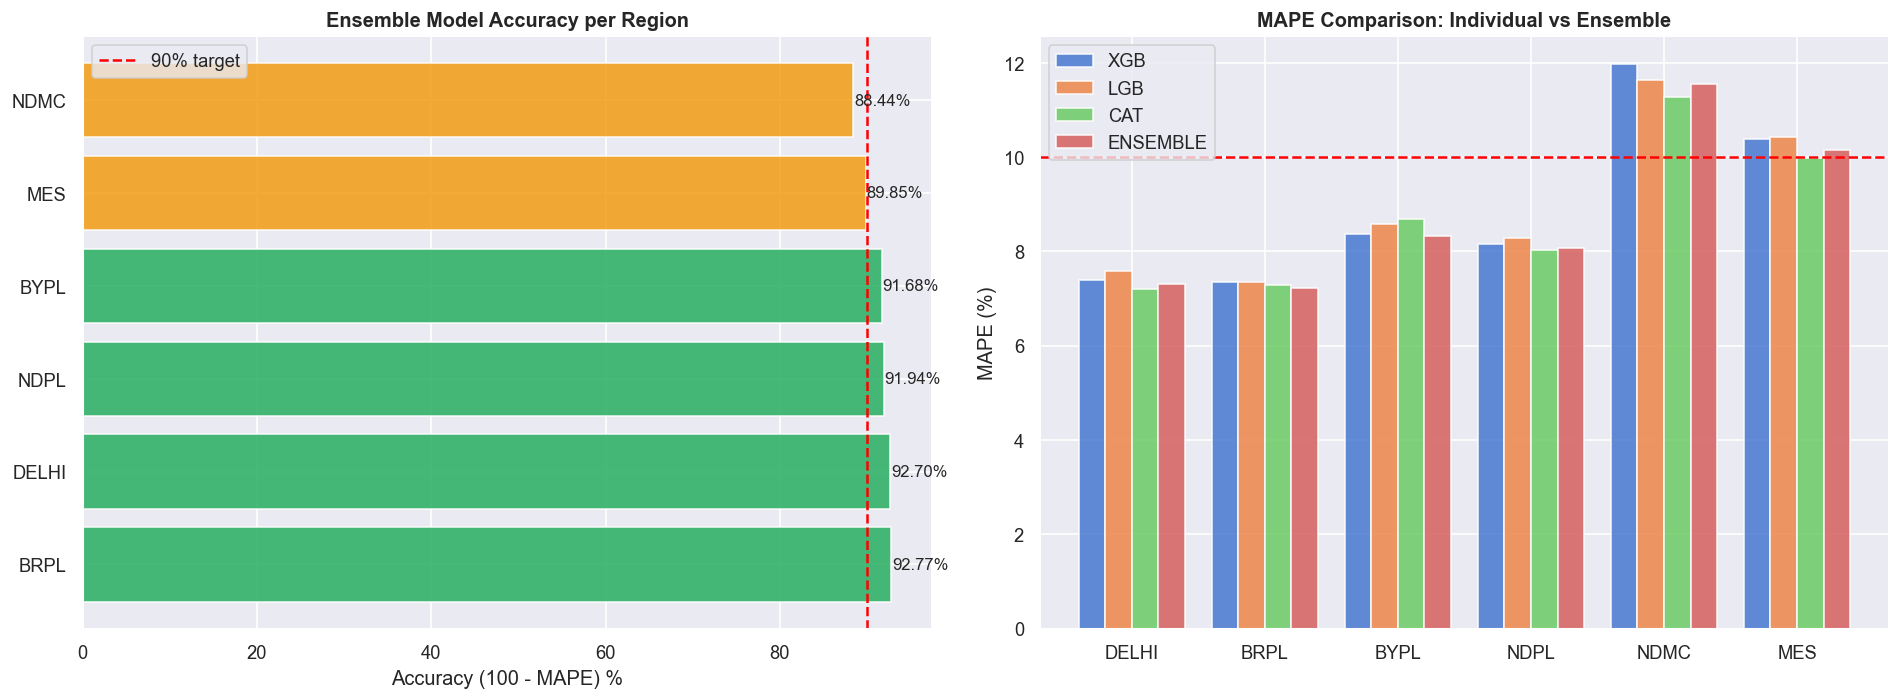

In [41]:
ens_only_sorted = ens_only.sort_values('Accuracy', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
colors = ['#27ae60' if a >= 90 else '#f39c12' if a >= 85 else '#e74c3c' for a in ens_only_sorted['Accuracy']]
bars = axes[0].barh(ens_only_sorted['region'], ens_only_sorted['Accuracy'], color=colors, alpha=0.85)
axes[0].axvline(90, color='red', linestyle='--', label='90% target')
axes[0].set_xlabel('Accuracy (100 - MAPE) %')
axes[0].set_title('Ensemble Model Accuracy per Region', fontweight='bold')
axes[0].legend()
for bar, v in zip(bars, ens_only_sorted['Accuracy']):
    axes[0].text(v+0.1, bar.get_y()+bar.get_height()/2, f'{v:.2f}%', va='center', fontsize=10)

# MAPE comparison: XGB vs LGB vs CAT vs Ensemble per region
x = np.arange(len(REGIONS))
w = 0.2
for i, model in enumerate(['XGB','LGB','CAT','ENSEMBLE']):
    vals = [metrics_df[metrics_df['region']==f'{r}_{model}']['MAPE'].values[0] for r in REGIONS]
    axes[1].bar(x + i*w, vals, width=w, label=model, alpha=0.85)
axes[1].set_xticks(x + 1.5*w); axes[1].set_xticklabels(REGIONS)
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('MAPE Comparison: Individual vs Ensemble', fontweight='bold')
axes[1].legend()
axes[1].axhline(10, color='red', linestyle='--', label='10% MAPE target')

plt.tight_layout()
plt.savefig('06_accuracy_comparison.png', bbox_inches='tight')
plt.show()

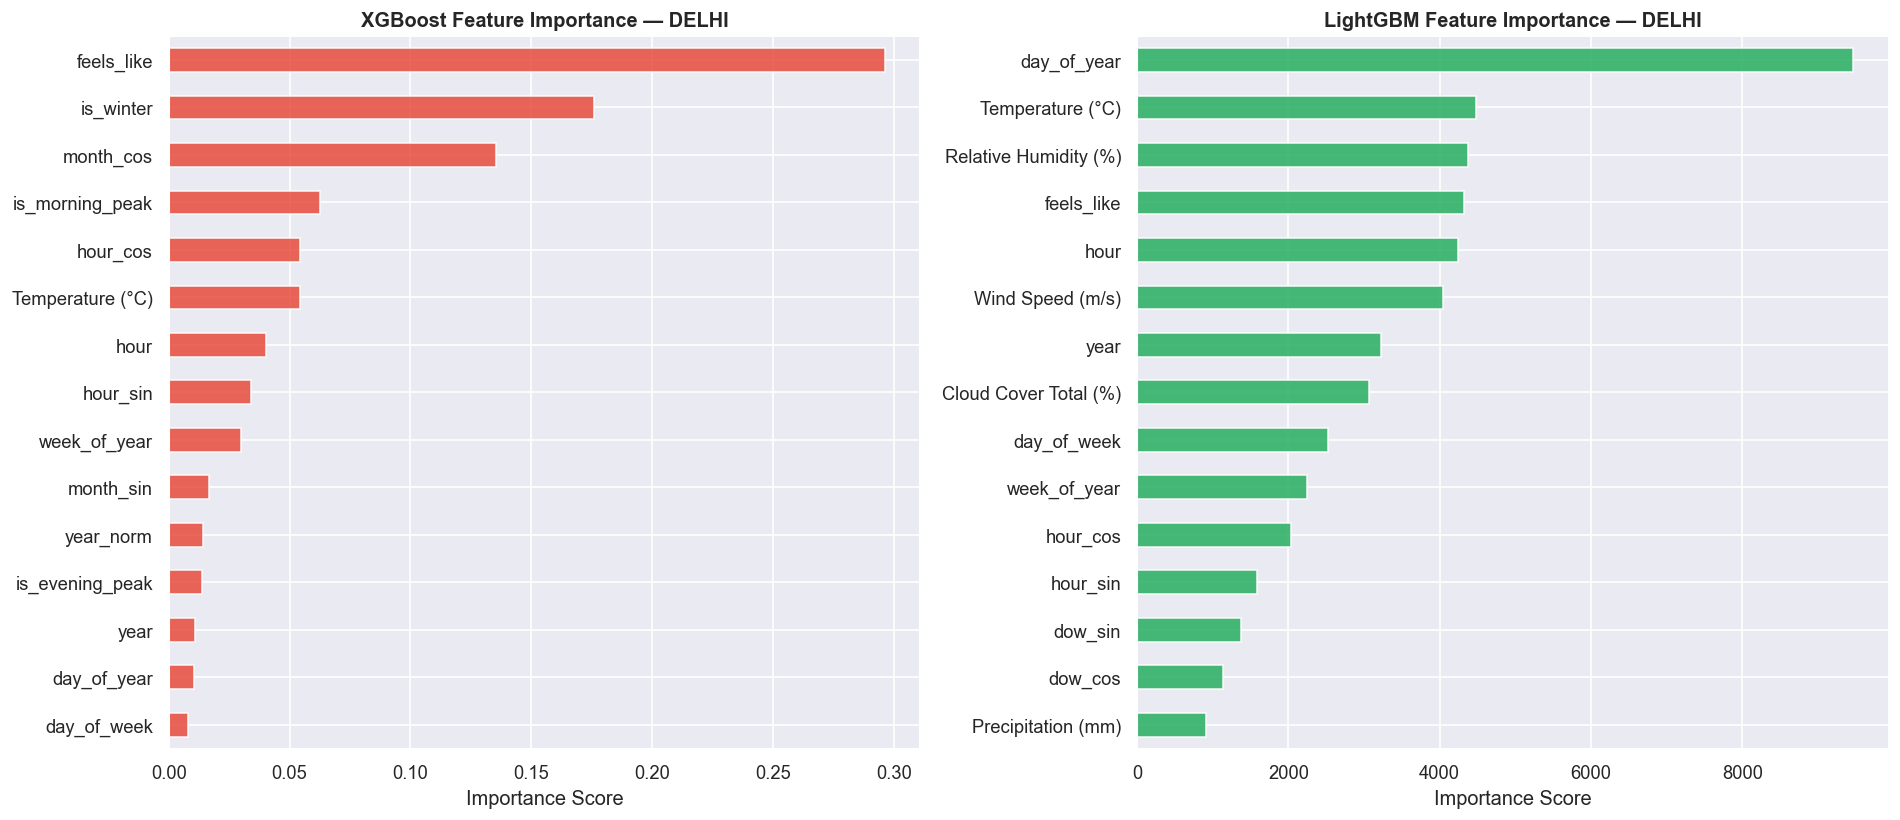

Top 5 features (XGBoost): ['feels_like', 'is_winter', 'month_cos', 'is_morning_peak', 'hour_cos']
Top 5 features (LightGBM): ['day_of_year', 'Temperature (°C)', 'Relative Humidity (%)', 'feels_like', 'hour']


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# XGBoost feature importance for DELHI
xgb_imp = pd.Series(all_models['DELHI']['xgb'].feature_importances_, index=FEATURES).sort_values(ascending=True)
xgb_imp.tail(15).plot(kind='barh', ax=axes[0], color='#e74c3c', alpha=0.85)
axes[0].set_title('XGBoost Feature Importance — DELHI', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# LightGBM feature importance for DELHI
lgb_imp = pd.Series(all_models['DELHI']['lgb'].feature_importances_, index=FEATURES).sort_values(ascending=True)
lgb_imp.tail(15).plot(kind='barh', ax=axes[1], color='#27ae60', alpha=0.85)
axes[1].set_title('LightGBM Feature Importance — DELHI', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('08_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features (XGBoost):', list(xgb_imp.tail(5).index[::-1]))
print('Top 5 features (LightGBM):', list(lgb_imp.tail(5).index[::-1]))

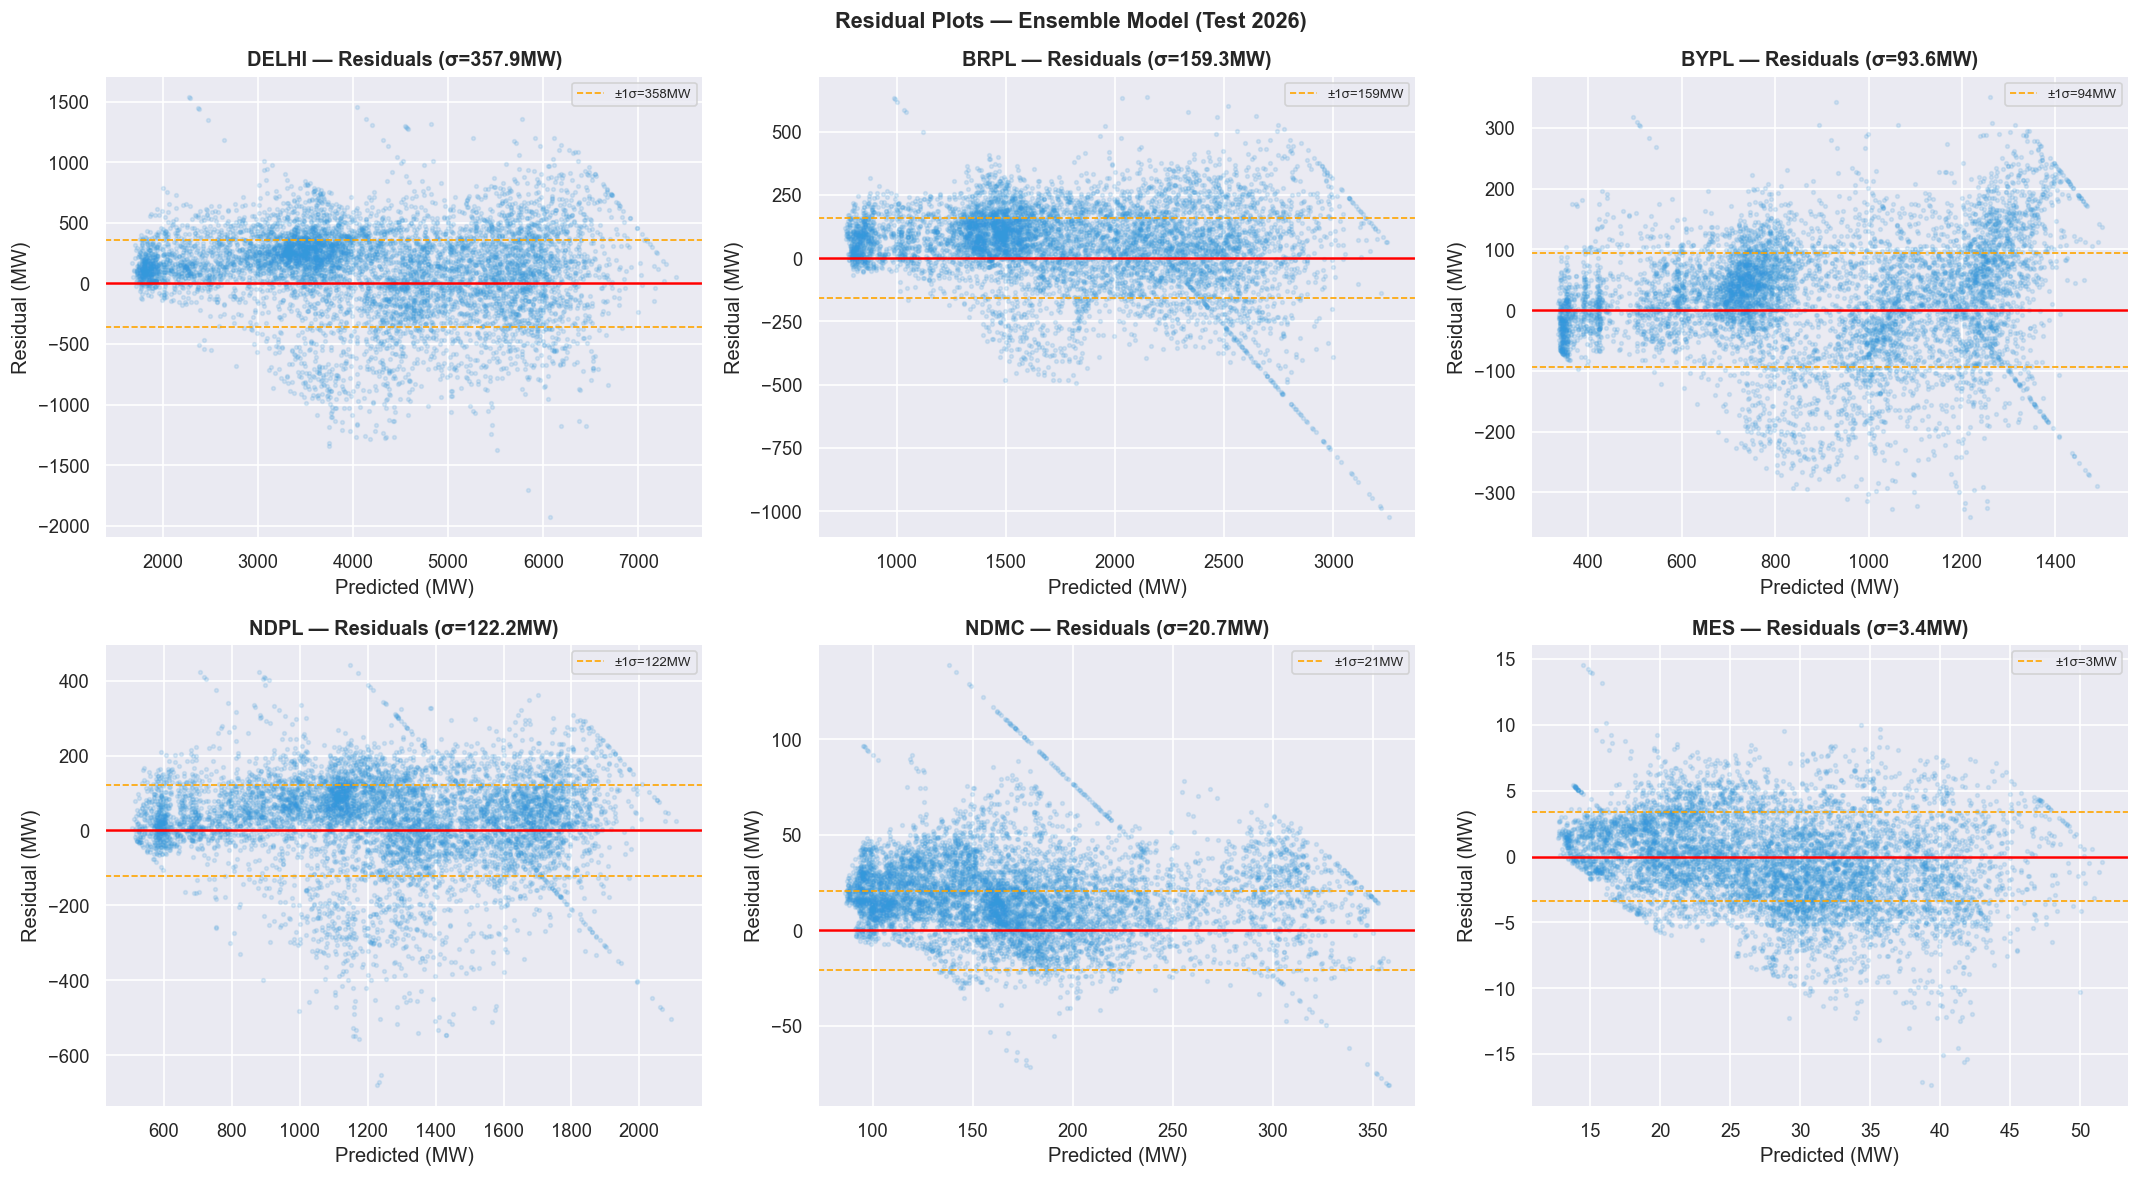

Residual std by region (lower = less variance = better):
  DELHI: σ=357.86 MW, mean=110.59 MW (bias)
  BRPL: σ=159.33 MW, mean=52.06 MW (bias)
  BYPL: σ=93.56 MW, mean=17.90 MW (bias)
  NDPL: σ=122.17 MW, mean=25.57 MW (bias)
  NDMC: σ=20.68 MW, mean=17.45 MW (bias)
  MES: σ=3.38 MW, mean=-0.40 MW (bias)


In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, r in enumerate(REGIONS):
    actual   = test_df[r].values
    pred     = all_preds[r]
    residuals = actual - pred
    
    axes[i].scatter(pred, residuals, alpha=0.15, s=5, color='#3498db')
    axes[i].axhline(0, color='red', linewidth=1.5)
    axes[i].axhline(residuals.std(), color='orange', linestyle='--', linewidth=1, label=f'±1σ={residuals.std():.0f}MW')
    axes[i].axhline(-residuals.std(), color='orange', linestyle='--', linewidth=1)
    axes[i].set_xlabel('Predicted (MW)')
    axes[i].set_ylabel('Residual (MW)')
    axes[i].set_title(f'{r} — Residuals (σ={residuals.std():.1f}MW)', fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Residual Plots — Ensemble Model (Test 2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('09_residuals.png', bbox_inches='tight')
plt.show()

print('Residual std by region (lower = less variance = better):')
for r in REGIONS:
    res = test_df[r].values - all_preds[r]
    print(f'  {r}: σ={res.std():.2f} MW, mean={res.mean():.2f} MW (bias)')

In [47]:
os.makedirs('models', exist_ok=True)

for region in REGIONS:
    # Save individual models
    joblib.dump(all_models[region]['xgb'], f'models/{region}_xgboost.pkl')
    joblib.dump(all_models[region]['lgb'], f'models/{region}_lightgbm.pkl')
    joblib.dump(all_models[region]['cat'], f'models/{region}_catboost.pkl')
    # Save ensemble weights
    joblib.dump(all_weights[region], f'models/{region}_weights.pkl')

# Save features list and metadata
metadata = {
    'features': FEATURES,
    'regions': REGIONS,
    'holiday_set': list(HOLIDAY_SET),
    'train_end': '2025-12-31',
    'test_start': '2026-01-01'
}
joblib.dump(metadata, 'models/metadata.pkl')

# List saved files
print('✅ Saved models:')
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f} ({size:.1f} KB)')

✅ Saved models:
  models/.ipynb_checkpoints (0.0 KB)
  models/BRPL_catboost.pkl (1043.6 KB)
  models/BRPL_lightgbm.pkl (950.8 KB)
  models/BRPL_weights.pkl (0.2 KB)
  models/BRPL_xgboost.pkl (1088.4 KB)
  models/BYPL_catboost.pkl (214.0 KB)
  models/BYPL_lightgbm.pkl (664.0 KB)
  models/BYPL_weights.pkl (0.2 KB)
  models/BYPL_xgboost.pkl (953.6 KB)
  models/DELHI_catboost.pkl (1179.5 KB)
  models/DELHI_lightgbm.pkl (4513.2 KB)
  models/DELHI_weights.pkl (0.2 KB)
  models/DELHI_xgboost.pkl (2083.8 KB)
  models/MES_catboost.pkl (1064.3 KB)
  models/MES_lightgbm.pkl (3276.6 KB)
  models/MES_weights.pkl (0.2 KB)
  models/MES_xgboost.pkl (2327.7 KB)
  models/NDMC_catboost.pkl (587.8 KB)
  models/NDMC_lightgbm.pkl (1622.2 KB)
  models/NDMC_weights.pkl (0.2 KB)
  models/NDMC_xgboost.pkl (1679.2 KB)
  models/NDPL_catboost.pkl (867.5 KB)
  models/NDPL_lightgbm.pkl (1436.0 KB)
  models/NDPL_weights.pkl (0.2 KB)
  models/NDPL_xgboost.pkl (2245.9 KB)
  models/ensemble_weights.pkl (0.5 KB)
  models